In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler, Normalizer

In [3]:
df = pd.read_csv("salary_data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [19]:
# Add 2 outlier records to detect outliers
import pandas as pd

# Create outlier records
outlier1 = df.iloc[0].copy()
outlier1['Salary'] = 500000  # Extremely high salary (outlier)

outlier2 = df.iloc[1].copy()
outlier2['Salary'] = 0   # Extremely low salary (outlier)

# Add outliers to dataframe
df = pd.concat([df, pd.DataFrame([outlier1, outlier2])], ignore_index=True)

print(f"Original dataframe size: {len(df) - 2}")
print(f"New dataframe size with outliers: {len(df)}")
print("\nDataframe with outliers:")
print(df.tail(2))
print(f"\nSalary statistics after adding outliers:")
print(df['Salary'].describe())

Original dataframe size: 375
New dataframe size with outliers: 377

Dataframe with outliers:
      Age  Gender Education Level          Job Title  Years of Experience  \
375  32.0    Male      Bachelor's  Software Engineer                  5.0   
376  28.0  Female        Master's       Data Analyst                  3.0   

       Salary  
375  500000.0  
376       0.0  

Salary statistics after adding outliers:
count       375.000000
mean     101374.266667
std       52608.352516
min           0.000000
25%       55000.000000
50%       95000.000000
75%      140000.000000
max      500000.000000
Name: Salary, dtype: float64


In [20]:
df.describe()

,Age,Years of Experience,Salary
count,375.000000,375.000000,375.000000
mean,37.392000,9.998667,101374.266667
std,7.072462,6.554635,52608.352516
min,23.000000,0.000000,0.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,500000.000000


In [26]:
new_df = df.copy()

# Standard Scaler
std_scaler = StandardScaler()
new_df["salary_stdscaled"] = std_scaler.fit_transform(new_df[["Salary"]])

# Min-Max Scaler
minmax_scaler = MinMaxScaler()
new_df["salary_minmaxscaled"] = minmax_scaler.fit_transform(new_df[['Salary']])

new_df[["Salary", "salary_stdscaled", "salary_minmaxscaled"]].head()

,Salary,salary_stdscaled,salary_minmaxscaled
0,90000.0,-0.216495,0.18
1,65000.0,-0.692340,0.13
2,150000.0,0.925532,0.30
3,60000.0,-0.787509,0.12
4,200000.0,1.877221,0.40


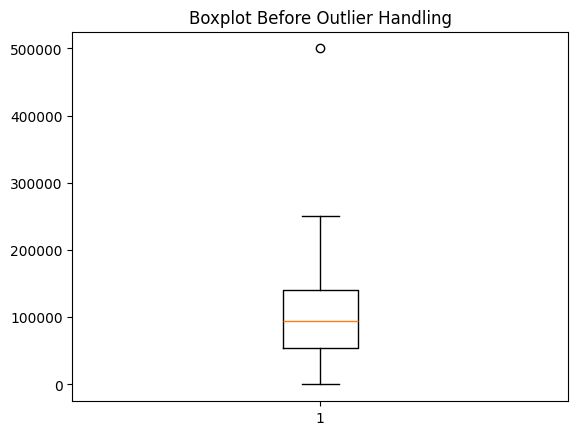

In [27]:
plt.figure()
# plt.boxplot(df['Age'])
plt.boxplot(df['Salary'].dropna())

plt.title('Boxplot Before Outlier Handling')
plt.show()

In [16]:
# Check the data and diagnose the issue
print("Column names:", df.columns.tolist())
print("\nDataFrame shape:", df.shape)
print("\nFirst few rows of new_df:")
print(new_df.head())
print("\nData types:")
print(new_df.dtypes)
print("\nNull values:")
print(new_df.isnull().sum())
print("\nSalary scaled values (first 10):")
print(new_df['salary_minmaxscaled'].head(10))

Column names: ['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']

DataFrame shape: (375, 6)

First few rows of new_df:
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  salary_stdscaled  salary_minmaxscaled  
0   90000.0         -0.219559             0.359103  
1   65000.0         -0.738498             0.258963  
2  150000.0          1.025892             0.599439  
3   60000.0         -0.842285             0.238935  
4  200000.0          2.063768             0.799720  

Data types:
Age                    float64
Gender                  object
Educa

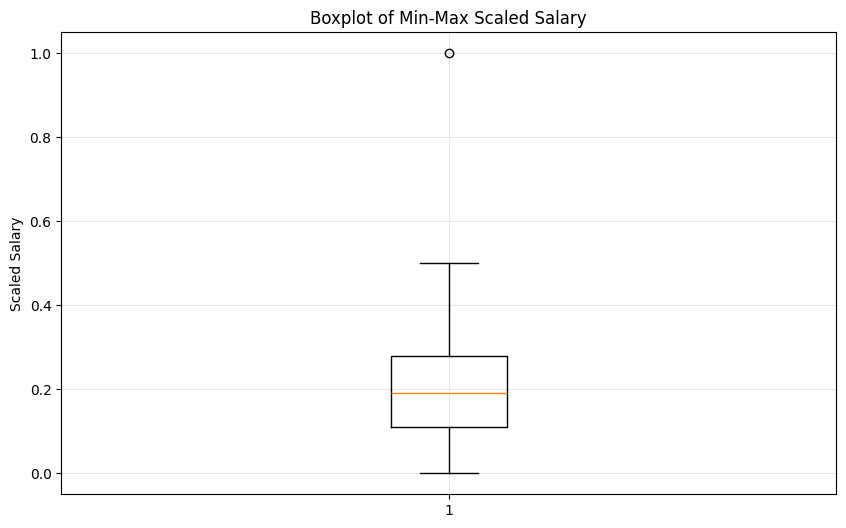

Plotted 375 data points


In [28]:
# Create boxplot with proper handling
plt.figure(figsize=(10, 6))

# Remove any NaN values before plotting
salary_data = new_df['salary_minmaxscaled'].dropna()

plt.boxplot(salary_data)
plt.title('Boxplot of Min-Max Scaled Salary')
plt.ylabel('Scaled Salary')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Plotted {len(salary_data)} data points")

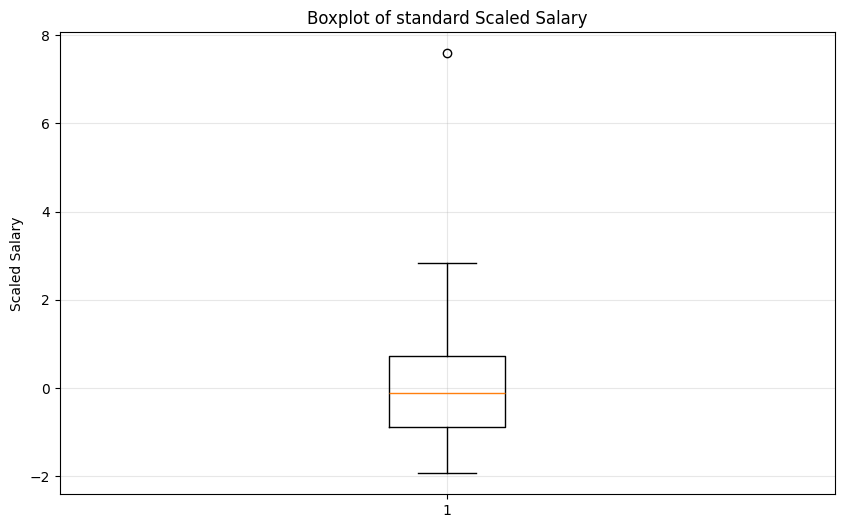

Plotted 375 data points


In [29]:
# Create boxplot with proper handling
plt.figure(figsize=(10, 6))

# Remove any NaN values before plotting
salary_data = new_df['salary_stdscaled'].dropna()

plt.boxplot(salary_data)
plt.title('Boxplot of standard Scaled Salary')
plt.ylabel('Scaled Salary')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Plotted {len(salary_data)} data points")

In [30]:
# Outlier Detection Methods

# Method 1: IQR (Interquartile Range)
Q1 = new_df['Salary'].quantile(0.25)
Q3 = new_df['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = new_df[(new_df['Salary'] < lower_bound) | (new_df['Salary'] > upper_bound)]

print("=" * 60)
print("METHOD 1: IQR (Interquartile Range)")
print("=" * 60)
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
print(f"\nOutliers detected: {len(outliers_iqr)}")
print(outliers_iqr[['Salary']])

# Method 2: Z-Score
from scipy import stats

z_scores = np.abs(stats.zscore(new_df['Salary']))
outliers_zscore = new_df[z_scores > 3]

print("\n" + "=" * 60)
print("METHOD 2: Z-Score (threshold > 3)")
print("=" * 60)
print(f"Outliers detected: {len(outliers_zscore)}")
print(outliers_zscore[['Salary']])

# Method 3: Remove outliers and re-scale
df_no_outliers = new_df[~new_df.index.isin(outliers_iqr.index)].copy()

print("\n" + "=" * 60)
print("COMPARISON")
print("=" * 60)
print(f"Original data rows: {len(new_df)}")
print(f"Data after removing outliers: {len(df_no_outliers)}")
print(f"Salary range before: {new_df['Salary'].min()} - {new_df['Salary'].max()}")
print(f"Salary range after: {df_no_outliers['Salary'].min()} - {df_no_outliers['Salary'].max()}")

METHOD 1: IQR (Interquartile Range)
Q1: 55000.0, Q3: 140000.0, IQR: 85000.0
Lower Bound: -72500.0, Upper Bound: 267500.0

Outliers detected: 1
       Salary
375  500000.0

METHOD 2: Z-Score (threshold > 3)
Outliers detected: 0
Empty DataFrame
Columns: [Salary]
Index: []

COMPARISON
Original data rows: 377
Data after removing outliers: 376
Salary range before: 0.0 - 500000.0
Salary range after: 0.0 - 250000.0


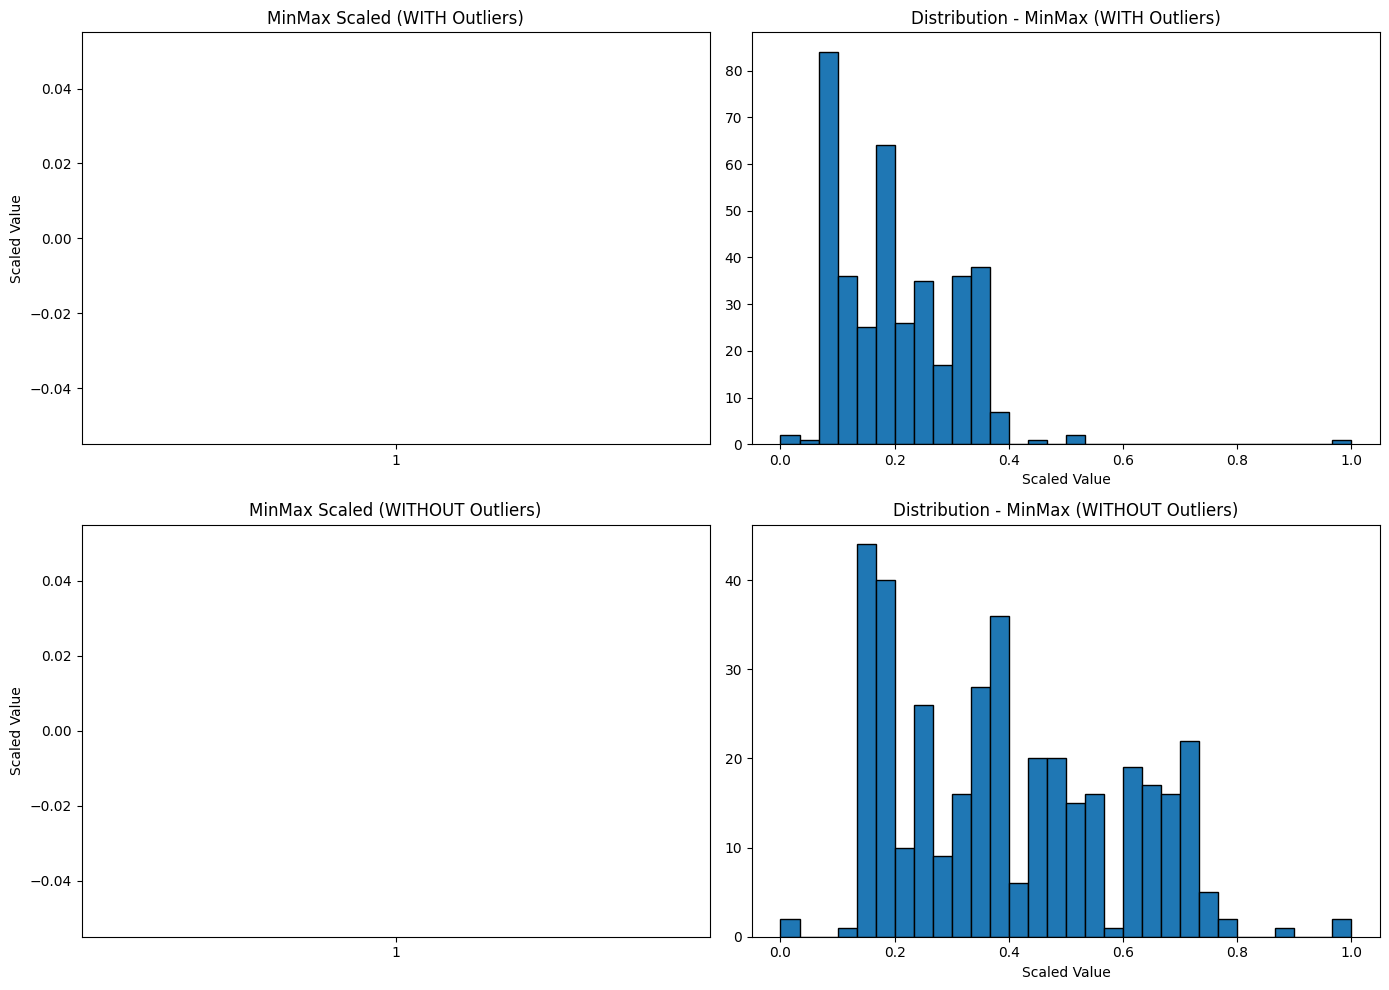


Notice the difference:
With outliers - scaled range: [0.0000, 1.0000]
Without outliers - scaled range: [0.0000, 1.0000]


In [31]:
# Visualize the difference: Scaling WITH vs WITHOUT outliers

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# WITH OUTLIERS
axes[0, 0].boxplot(new_df['salary_minmaxscaled'])
axes[0, 0].set_title('MinMax Scaled (WITH Outliers)')
axes[0, 0].set_ylabel('Scaled Value')

axes[0, 1].hist(new_df['salary_minmaxscaled'], bins=30, edgecolor='black')
axes[0, 1].set_title('Distribution - MinMax (WITH Outliers)')
axes[0, 1].set_xlabel('Scaled Value')

# WITHOUT OUTLIERS - Re-scale after removing
minmax_scaler_clean = MinMaxScaler()
df_no_outliers['salary_minmaxscaled_clean'] = minmax_scaler_clean.fit_transform(df_no_outliers[['Salary']])

axes[1, 0].boxplot(df_no_outliers['salary_minmaxscaled_clean'])
axes[1, 0].set_title('MinMax Scaled (WITHOUT Outliers)')
axes[1, 0].set_ylabel('Scaled Value')

axes[1, 1].hist(df_no_outliers['salary_minmaxscaled_clean'], bins=30, edgecolor='black')
axes[1, 1].set_title('Distribution - MinMax (WITHOUT Outliers)')
axes[1, 1].set_xlabel('Scaled Value')

plt.tight_layout()
plt.show()

print("\nNotice the difference:")
print(f"With outliers - scaled range: [{new_df['salary_minmaxscaled'].min():.4f}, {new_df['salary_minmaxscaled'].max():.4f}]")
print(f"Without outliers - scaled range: [{df_no_outliers['salary_minmaxscaled_clean'].min():.4f}, {df_no_outliers['salary_minmaxscaled_clean'].max():.4f}]")